In [1]:
import os
import re
import pickle
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, SnowballStemmer, PorterStemmer
from nltk.corpus import stopwords
import spacy
from matplotlib import pyplot as plt
from sklearn.feature_extraction.text import TfidfTransformer, CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from tqdm import tqdm

from scipy.sparse import csr_matrix
from gensim import corpora, models
from gensim.matutils import Sparse2Corpus

from scipy.stats import pearsonr
from scipy import sparse

import wordcloud
from wordcloud import WordCloud

In [2]:
import os
import subprocess
subprocess.Popen(['caffeinate', '-i', '-w', str(os.getpid())])
print("Caffeinate running — laptop won't sleep")

Caffeinate running — laptop won't sleep


In [ ]:
def download_nltk_resources():
    required_resources = ['wordnet', 'stopwords', 'punkt', 'punkt_tab']
    for resource in required_resources:
        try:
            nltk.data.find(f'tokenizers/{resource}' if resource == 'punkt' else f'corpora/{resource}')
        except LookupError:
            nltk.download(resource)

download_nltk_resources()

try:
    sp = spacy.load('en_core_web_sm')
except OSError:
    from spacy.cli import download as spacy_download

    print("Installing spaCy model 'en_core_web_sm' for this environment...")
    spacy_download('en_core_web_sm')
    sp = spacy.load('en_core_web_sm')

tqdm.pandas()

porter = SnowballStemmer("english")
lmtzr = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words('english'))


[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/andregarcia/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/andregarcia/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [4]:
"""
This module provides helper functions for text preprocessing. 
Each function applies punctuation removal and stopword removal, and then one of three options:
    0: Lowercasing only.
    1: Lowercasing plus stemming.
    2: Lemmatizing (using spaCy; original casing is preserved).

The functions return a string of tokens separated by spaces.
"""

def preprocess_lower(text):
    """
    Preprocess text by:
       - Converting to lowercase.
       - Removing punctuation.
       - Tokenizing.
       - Removing stopwords.
    
    Returns:
        str: A string of filtered tokens separated by spaces.
    """
    text_lower = text.lower()
    text_no_punct = re.sub(r'[^\w\s]', '', text_lower)
    tokens = word_tokenize(text_no_punct)
    filtered_tokens = [token for token in tokens if token not in STOP_WORDS]
    return " ".join(filtered_tokens)

def preprocess_stem(text):
    """
    Preprocess text by performing all steps in preprocess_lower() and then applying stemming.
    
    Returns:
        str: A string of stemmed tokens separated by spaces.
    """
    tokens = preprocess_lower(text).split()
    ps = PorterStemmer()
    stemmed_tokens = [ps.stem(token) for token in tokens]
    return " ".join(stemmed_tokens)

def preprocess_lemma(text):
    """
    Preprocess text by:
       - Removing punctuation and stopwords using spaCy's token attributes.
       - Lemmatizing the text.
       - (Note: This function does NOT lowercase the text.)
    
    Returns:
        str: A string of lemmatized tokens separated by spaces.
    """
    doc = sp(text)
    lemmatized_tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and token.lemma_.strip() != '']
    return " ".join(lemmatized_tokens)

def tokenize(text, mode=0):
    """
    General tokenize function. Always applies punctuation and stopword removal and then:
    
      mode = 0: Applies lowercasing.
      mode = 1: Applies lowercasing and stemming.
      mode = 2: Applies lemmatization (without lowercasing the original text).
    
    Args:
        text (str): The input text to be processed.
        mode (int): Processing mode (0 for lowercasing; 1 for stemming; 2 for lemmatizing).

    Returns:
        str: A string of processed tokens separated by spaces.

    Raises:
        ValueError: If an invalid mode is provided.
    """
    if mode == 0:
        return preprocess_lower(text)
    elif mode == 1:
        return preprocess_stem(text)
    elif mode == 2:
        return preprocess_lemma(text)
    else:
        raise ValueError("Invalid mode. Please use 0 for lowercasing, 1 for stemming, or 2 for lemmatizing.")


In [4]:
data_file = 'hansard.csv'
corpus_data = pd.read_csv(data_file, encoding='utf-8')

corpus_data = corpus_data.dropna(subset='speaker')
corpus_data.drop(columns=["file","speech_id","type","speaker_id", "colnum","time","url"], 
                 inplace=True)

corpus_data.info()
corpus_data.head()

/var/folders/sh/fyg2xxg50qxf8s19d34bzy2c0000gn/T/ipykernel_86876/1378335376.py:2: DtypeWarning: Columns (0: type, 1: speaker_id, 2: colnum, 3: url) have mixed types. Specify dtype option on import or set low_memory=False.
  corpus_data = pd.read_csv(data_file, encoding='utf-8')


<class 'pandas.DataFrame'>
Index: 4328210 entries, 5 to 4671401
Data columns (total 5 columns):
 #   Column      Dtype
---  ------      -----
 0   date        str  
 1   speaker     str  
 2   section     str  
 3   text        str  
 4   word_count  int64
dtypes: int64(1), str(4)
memory usage: 198.1 MB


,date,speaker,section,text,word_count
5,1952-01-29,Mr. Stephen Swingler,Re-armament and Essential Industries,asked the Minister of Labour whether he will m...,20
6,1952-01-29,Mr. Norman Dodds,Re-armament and Essential Industries,asked the Minister of Labour what proposals he...,26
7,1952-01-29,The Minister of Labour (Sir Walter Monckton),Re-armament and Essential Industries,I would ask the hon. Members to await the stat...,34
8,1952-01-29,Mr. Swingler,Re-armament and Essential Industries,asked the Minister of Labour what numbers of p...,28
9,1952-01-29,Sir W. Monckton,Re-armament and Essential Industries,I regret that it is not practicable to make su...,12


In [ ]:
data_file = 'csv_files/UK_monarch_speeches.csv'
monarch_data = pd.read_csv(data_file, encoding='utf-8')

monarch_data.drop(columns=["year","title","url"], 
                 inplace=True)
monarch_data.rename(columns={"monarch": "speaker", "speech": "text"}, inplace=True)
monarch_data['section'] = 'Monarch speech identifier'
monarch_data["word_count"] = monarch_data["text"].apply(lambda x: len(x.split()))

monarch_data.info()
monarch_data.head()

<class 'pandas.DataFrame'>
RangeIndex: 433 entries, 0 to 432
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   date        433 non-null    str  
 1   speaker     433 non-null    str  
 2   text        433 non-null    str  
 3   section     433 non-null    str  
 4   word_count  433 non-null    int64
dtypes: int64(1), str(4)
memory usage: 17.0 KB


,date,speaker,text,section,word_count
0,1952-12-25,Queen Elizabeth II,"Each Christmas, at this time, my beloved fathe...",Monarch speech identifier,690
1,1953-06-02,Queen Elizabeth II,"When I spoke to you last, at Christmas, I aske...",Monarch speech identifier,641
2,1953-06-02,Queen Elizabeth II,"In the Coronation ceremony of 2 June 1953, one...",Monarch speech identifier,451
3,1953-12-25,Queen Elizabeth II,Last Christmas I spoke to you from England; th...,Monarch speech identifier,900
4,1954-12-25,Queen Elizabeth II,It is now two years since my husband and I spe...,Monarch speech identifier,641


In [6]:
corpus_data = pd.concat([corpus_data, monarch_data], ignore_index=True)
corpus_data.tail()

,date,speaker,section,text,word_count
4328638,2025-12-12,King Charles III,Monarch speech identifier,This is a season when our thoughts turn to cel...,636
4328639,2025-12-19,King Charles III,Monarch speech identifier,"Ladies and gentlemen, I am delighted to be abl...",886
4328640,2026-02-11,King Charles III,Monarch speech identifier,My wife and I were profoundly shocked and sadd...,365
4328641,2026-02-12,King Charles III,Monarch speech identifier,So to those who provide care - whether you wea...,754
4328642,2026-02-18,King Charles III,Monarch speech identifier,My wife and I were deeply saddened to hear of ...,96


In [ ]:
mod = 1

try:
    corpus_data["text"] = corpus_data.text.astype(str).progress_apply(lambda row: tokenize(row, mod))
    corpus_data["word_count"] = corpus_data.text.progress_apply(lambda x: len(x.split()))
    print("Done processing text.")
except Exception as e:
    print(f"Error processing text column: {e}")
    raise RuntimeError(f"Error processing text column: {e}") from e

100%|██████████| 4328643/4328643 [00:05<00:00, 758996.68it/s] 

Done processing text.


In [ ]:
#checkpoint 1
corpus_data.to_csv("csv_files/speeches_processed.csv", index=False)

In [ ]:
data_file = 'csv_files/speeches_processed.csv'
corpus_data = pd.read_csv(data_file, encoding='utf-8')

corpus_data = corpus_data[corpus_data['word_count']>20]
corpus_data.reset_index(drop=True, inplace=True)
corpus_data = corpus_data[['date','speaker','section','text','word_count']]
corpus_data.head()

,date,speaker,section,text,word_count
0,1952-01-29,Mr. Swingler,Re-armament and Essential Industries,view fact minist made number statement speech ...,22
1,1952-01-29,Sir W. Monckton,Re-armament and Essential Industries,difficulti make estim chang occup peopl precis...,27
2,1952-01-29,Sir W. Monckton,Coalmining (Italian Workers),presum hon member refer italian worker brought...,24
3,1952-01-29,Sir W. Monckton,Textiles and Clothing,latest date figur avail 10th decemb date 7379 ...,39
4,1952-01-29,Sir W. Monckton,Textiles and Clothing,refer temporari phase due fact earli decemb nu...,43


In [6]:
cv = CountVectorizer(ngram_range = (1,2), lowercase=True, min_df=0.005, max_df=0.7)
cv.fit(corpus_data["text"])
vectorized_text=cv.transform(corpus_data["text"])
vectorized_text.shape

(2566390, 1791)

In [ ]:
# Checkpoint 2
sparse.save_npz('vectorized_data/vectorized_text.npz', vectorized_text)
with open('vectorized_data/cv_vectorizer.pkl', 'wb') as f:
    pickle.dump(cv, f)

In [ ]:
# Load
vectorized_text = sparse.load_npz('vectorized_data/vectorized_text.npz')
with open('vectorized_data/cv_vectorizer.pkl', 'rb') as f:
    cv = pickle.load(f)

In [ ]:
dtm_sparse = csr_matrix(vectorized_text)

# Convert sparse matrix to gensim corpus
corpus = Sparse2Corpus(dtm_sparse, documents_columns=False)

vocabulary_gensim = {}
for key, val in cv.vocabulary_.items():
    vocabulary_gensim[val] = key

dictionary = corpora.Dictionary()
dictionary.id2token = vocabulary_gensim
dictionary.token2id = cv.vocabulary_

In [8]:
help(models.LdaMulticore)

Help on class LdaMulticore in module gensim.models.ldamulticore:

class LdaMulticore(gensim.models.ldamodel.LdaModel)
 |  LdaMulticore(corpus=None, num_topics=100, id2word=None, workers=None, chunksize=2000, passes=1, batch=False, alpha='symmetric', eta=None, decay=0.5, offset=1.0, eval_every=10, iterations=50, gamma_threshold=0.001, random_state=None, minimum_probability=0.01, minimum_phi_value=0.01, per_word_topics=False, dtype=<class 'numpy.float32'>)
 |  
 |  An optimized implementation of the LDA algorithm, able to harness the power of multicore CPUs.
 |  Follows the similar API as the parent class :class:`~gensim.models.ldamodel.LdaModel`.
 |  
 |  Method resolution order:
 |      LdaMulticore
 |      gensim.models.ldamodel.LdaModel
 |      gensim.interfaces.TransformationABC
 |      gensim.utils.SaveLoad
 |      gensim.models.basemodel.BaseTopicModel
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self, corpus=None, num_topics=100, id2word=None, workers=

In [ ]:
topic_sizes = [8, 5, 10, 15, 25]

for num_topics in tqdm(topic_sizes, desc="Training LDA models"):
    print(f"\nTraining model with {num_topics} topics")
    
    lda_model = models.LdaMulticore(corpus=corpus,
                                    id2word=dictionary,
                                    num_topics=num_topics,
                                    workers=8,
                                    passes=20,
                                    random_state=123)
    
    # Save checkpoint
    with open(f'lda_models/lda_model_{num_topics}_topics.pkl', 'wb') as f:
        pickle.dump(lda_model, f)
    
    print(f"Saved lda_model_{num_topics}_topics.pkl")

print("\nAll models trained and saved")

Training LDA models:   0%|          | 0/5 [00:00<?, ?it/s]


Training model with 8 topics...


Training LDA models:  20%|██        | 1/5 [1:12:51<4:51:25, 4371.41s/it]

Saved lda_model_8_topics.pkl

Training model with 5 topics...


Training LDA models:  40%|████      | 2/5 [2:25:42<3:38:34, 4371.47s/it]

...

Saved lda_model_10_topics.pkl

Training model with 15 topics...


Training LDA models:  80%|████████  | 4/5 [4:50:32<1:12:34, 4354.22s/it]

Saved lda_model_15_topics.pkl

Training model with 25 topics...


Training LDA models: 100%|██████████| 5/5 [6:01:38<00:00, 4339.63s/it]  

Saved lda_model_25_topics.pkl

All models trained and saved


In [ ]:
topics = lda_model.print_topics(num_words=50)
for topic in topics:
    print(topic)
    print("    ")

In [10]:
topic_sizes = [5, 8, 10, 15, 25]

for num_topics in topic_sizes:
    with open(f'lda_models/lda_model_{num_topics}_topics.pkl', 'rb') as f:
        lda_model = pickle.load(f)
    
    print(f"MODEL: {num_topics} TOPICS")
    
    topics = lda_model.print_topics(num_words=50)
    for topic in topics:
        print(topic)
        print()

MODEL: 5 TOPICS
(0, '0.018*"state" + 0.017*"secretari" + 0.016*"minist" + 0.015*"govern" + 0.013*"secretari state" + 0.013*"uk" + 0.011*"prime" + 0.010*"countri" + 0.010*"prime minist" + 0.008*"unit" + 0.007*"european" + 0.007*"northern" + 0.007*"ireland" + 0.007*"trade" + 0.007*"intern" + 0.007*"union" + 0.007*"nation" + 0.007*"british" + 0.006*"eu" + 0.006*"northern ireland" + 0.006*"us" + 0.006*"secur" + 0.006*"right" + 0.006*"world" + 0.005*"support" + 0.005*"scotland" + 0.005*"forc" + 0.005*"kingdom" + 0.005*"defenc" + 0.005*"unit kingdom" + 0.004*"continu" + 0.004*"take" + 0.004*"foreign" + 0.004*"import" + 0.004*"scottish" + 0.004*"peopl" + 0.004*"agre" + 0.004*"would" + 0.004*"agreement" + 0.004*"need" + 0.004*"also" + 0.004*"make" + 0.004*"work" + 0.003*"commit" + 0.003*"part" + 0.003*"must" + 0.003*"ensur" + 0.003*"negoti" + 0.003*"arm" + 0.003*"made"')

(1, '0.103*"hon" + 0.054*"friend" + 0.049*"hon friend" + 0.040*"right" + 0.027*"right hon" + 0.026*"gentleman" + 0.025*"hon

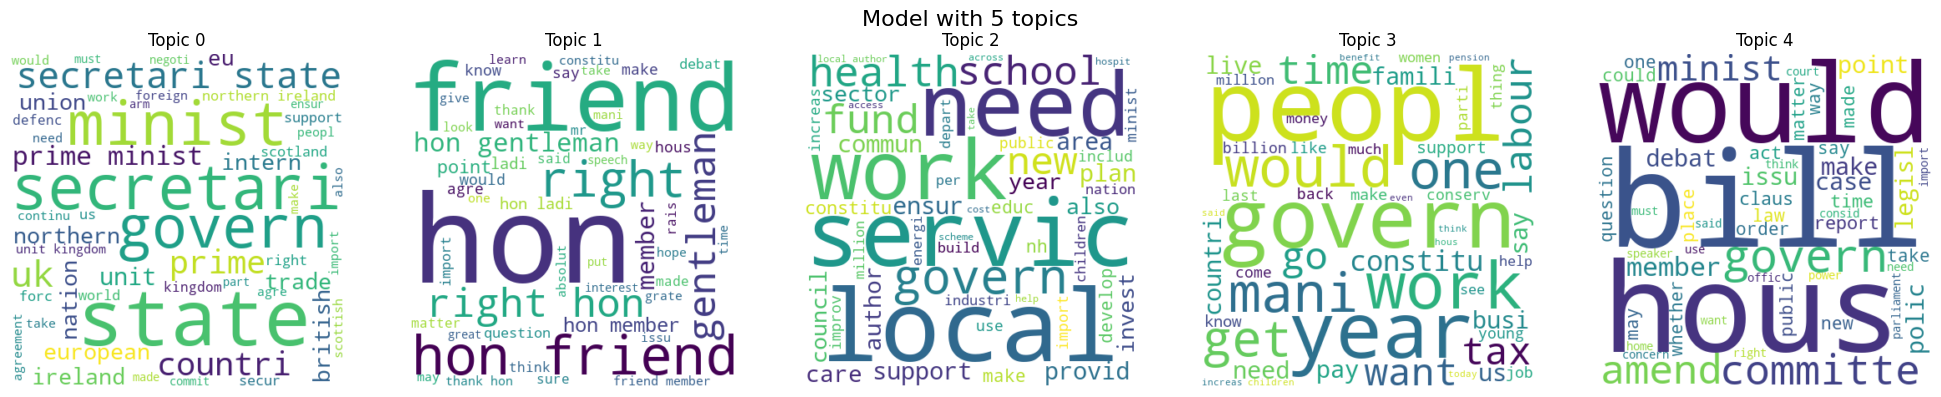

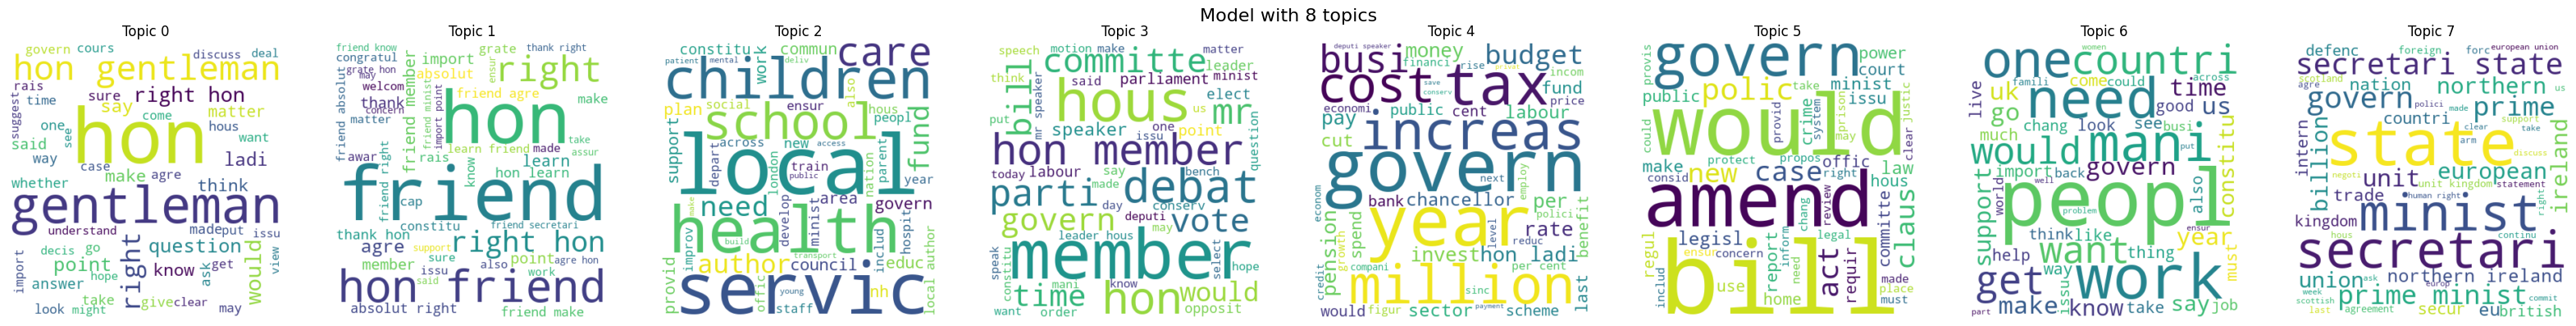

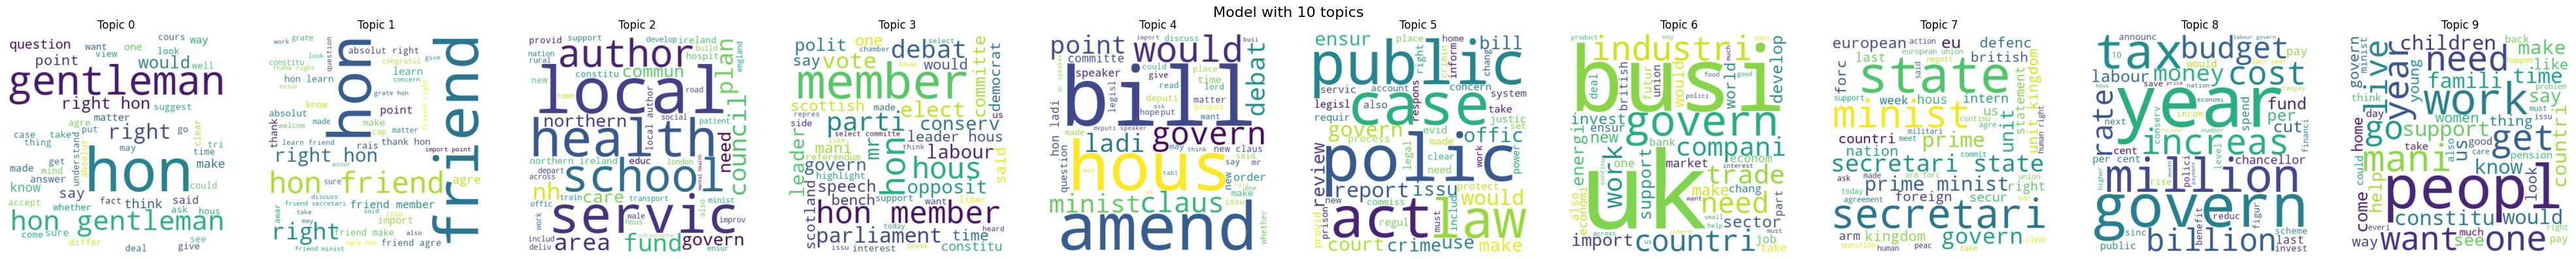

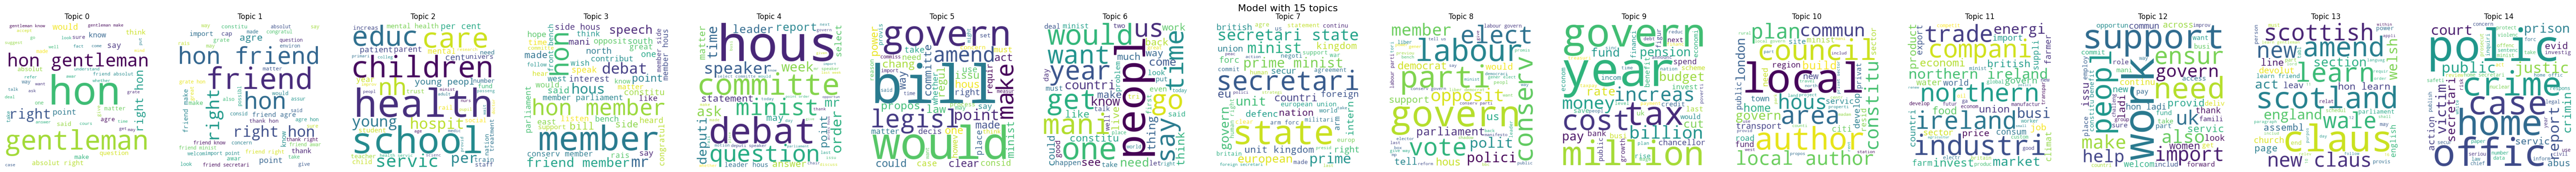

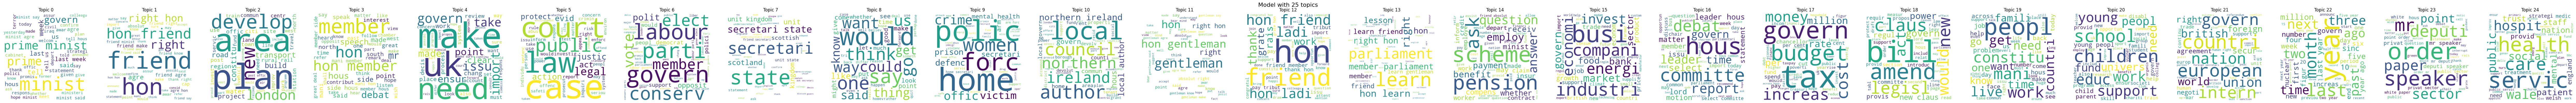

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import re

topic_sizes = [5, 8, 10, 15, 25]

for num_topics in topic_sizes:
    with open(f'lda_models/lda_model_{num_topics}_topics.pkl', 'rb') as f:
        lda_model = pickle.load(f)
    
    fig, axes = plt.subplots(1, num_topics, figsize=(num_topics * 4, 4))
    fig.suptitle(f'Model with {num_topics} topics', fontsize=16)
    
    for topic_id in range(num_topics):
        topic_terms = lda_model.show_topic(topic_id, topn=50)
        word_freq = {word: weight for word, weight in topic_terms}
        
        wc = WordCloud(width=400, height=400, background_color='white')
        wc.generate_from_frequencies(word_freq)
        
        ax = axes[topic_id] if num_topics > 1 else axes
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'Topic {topic_id}')
        ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(f'word_clouds/wordcloud_{num_topics}_topics.png', dpi=150, bbox_inches='tight')
    plt.show()

In [12]:
print(topics[16])

(np.int64(18), '0.098*"bill" + 0.046*"amend" + 0.028*"claus" + 0.025*"legisl" + 0.024*"new" + 0.021*"would" + 0.018*"act" + 0.016*"govern" + 0.014*"power" + 0.013*"new claus" + 0.013*"regul" + 0.013*"provis" + 0.010*"committe" + 0.009*"requir" + 0.008*"section" + 0.008*"introduc" + 0.008*"propos" + 0.007*"support" + 0.007*"hous" + 0.007*"measur" + 0.007*"provid" + 0.007*"leav" + 0.007*"read" + 0.007*"line" + 0.006*"order" + 0.006*"law" + 0.006*"relat" + 0.006*"includ" + 0.006*"tabl" + 0.005*"lord" + 0.005*"page" + 0.005*"draft" + 0.005*"second" + 0.005*"protect" + 0.005*"right" + 0.005*"parliament" + 0.005*"allow" + 0.005*"chang" + 0.005*"appli" + 0.005*"part" + 0.005*"purpos" + 0.005*"may" + 0.004*"end" + 0.004*"effect" + 0.004*"place" + 0.004*"pass" + 0.004*"seek" + 0.004*"use" + 0.004*"reason" + 0.004*"remov"')


In [ ]:
num_topics = 15
with open(f'lda_models/lda_model_{num_topics}_topics.pkl', 'rb') as f:
        lda_model = pickle.load(f)

doc_topics = [lda_model.get_document_topics(item, minimum_probability=0.0000001) for item in corpus]

for topic_num in range(num_topics):
    corpus_data[f'topic_{topic_num}'] = 0.0

for i, doc_distribution in enumerate(doc_topics):
    for topic_num, prob in doc_distribution:
        corpus_data.at[i, f'topic_{topic_num}'] = prob


In [ ]:
#checkpoint 3 (optional)
corpus_data.to_csv("csv_files/speeches_processed_2.csv", index=False)

In [ ]:
corpus_data = pd.read_csv("csv_files/speeches_processed_2.csv", encoding='utf-8')

In [6]:
corpus_data.head()

,date,speaker,section,text,word_count,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,topic_11,topic_12,topic_13,topic_14
0,1952-01-29,Mr. Swingler,Re-armament and Essential Industries,view fact minist made number statement speech ...,22,0.003175,0.003175,0.003175,0.086084,0.147809,0.350599,0.003175,0.140302,0.003175,0.118695,0.003175,0.127936,0.003175,0.003175,0.003175
1,1952-01-29,Sir W. Monckton,Re-armament and Essential Industries,difficulti make estim chang occup peopl precis...,27,0.002778,0.002778,0.002778,0.002778,0.002778,0.002778,0.425199,0.050531,0.002778,0.242058,0.002778,0.002778,0.251652,0.002778,0.002778
2,1952-01-29,Sir W. Monckton,Coalmining (Italian Workers),presum hon member refer italian worker brought...,24,0.003175,0.003175,0.003175,0.259728,0.003175,0.003175,0.171588,0.003175,0.003175,0.003175,0.003175,0.003175,0.530583,0.003175,0.003175
3,1952-01-29,Sir W. Monckton,Textiles and Clothing,latest date figur avail 10th decemb date 7379 ...,39,0.002382,0.002382,0.002382,0.002382,0.002382,0.002382,0.002382,0.002382,0.002382,0.486225,0.002382,0.254946,0.230249,0.002382,0.002382
4,1952-01-29,Sir W. Monckton,Textiles and Clothing,refer temporari phase due fact earli decemb nu...,43,0.001667,0.207303,0.001667,0.001667,0.236394,0.001667,0.238762,0.001667,0.001667,0.240578,0.001667,0.060294,0.001667,0.001667,0.001667


In [7]:
topic_cols = [col for col in corpus_data.columns if col.startswith('topic_')]


daily_sum = corpus_data.assign(
    **{col: corpus_data[col] * corpus_data['word_count'] for col in topic_cols}
).groupby('date')[topic_cols + ['word_count']].sum()


final_daily_vectors = daily_sum[topic_cols].div(daily_sum['word_count'], axis=0).reset_index()

print(final_daily_vectors.head())

         date   topic_0   topic_1   topic_2   topic_3   topic_4   topic_5  \
0  1952-01-29  0.119180  0.040354  0.023281  0.087074  0.083845  0.125554   
1  1952-01-30  0.139381  0.024678  0.029507  0.100775  0.132634  0.096749   
2  1952-01-31  0.151130  0.053115  0.068594  0.111990  0.060648  0.095877   
3  1952-02-01  0.089147  0.040224  0.010543  0.231514  0.044122  0.236855   
4  1952-02-04  0.116695  0.041579  0.012481  0.128076  0.093482  0.103984   

    topic_6   topic_7   topic_8   topic_9  topic_10  topic_11  topic_12  \
0  0.110064  0.090086  0.006898  0.101690  0.058243  0.056908  0.026109   
1  0.099697  0.124915  0.041803  0.070805  0.023849  0.045995  0.011881   
2  0.118414  0.061147  0.030875  0.070630  0.023699  0.081701  0.012577   
3  0.146859  0.016261  0.011676  0.016548  0.027177  0.026833  0.028256   
4  0.099369  0.060333  0.015141  0.047093  0.042865  0.120476  0.022727   

   topic_13  topic_14  
0  0.021442  0.049273  
1  0.006222  0.051109  
2  0.011802  0

In [8]:
corpus_data['date'] = pd.to_datetime(corpus_data['date'])
corpus_data['year'] = corpus_data['date'].dt.year

In [ ]:
royal_speeches = corpus_data[corpus_data['section'] == 'Monarch speech identifier']

royal_sum = royal_speeches.assign(
    **{col: royal_speeches[col] * royal_speeches['word_count'] for col in topic_cols}
).groupby('year')[topic_cols + ['word_count']].sum()

royal_vectors = royal_sum[topic_cols].div(royal_sum['word_count'], axis=0).reset_index()

royal_vectors = royal_vectors.rename(columns={col: f'{col}_r' for col in topic_cols})

royal_vectors.head()

,year,topic_0_r,topic_1_r,topic_2_r,topic_3_r,topic_4_r,topic_5_r,topic_6_r,topic_7_r,topic_8_r,topic_9_r,topic_10_r,topic_11_r,topic_12_r,topic_13_r,topic_14_r
0,1952,0.000283,0.000283,0.061567,0.010881,0.078949,0.000283,0.644852,0.085312,0.000283,0.000283,0.000283,0.000283,0.100849,0.015330,0.000283
1,1953,0.000310,0.000310,0.016469,0.000310,0.047780,0.036832,0.518089,0.227587,0.000310,0.002049,0.012717,0.011447,0.057687,0.042528,0.025575
2,1954,0.000337,0.000337,0.033080,0.000337,0.042548,0.000337,0.743169,0.013906,0.000337,0.041353,0.000337,0.000337,0.122915,0.000337,0.000337
3,1955,0.000237,0.000237,0.000237,0.046173,0.000237,0.066487,0.557044,0.204828,0.000237,0.011092,0.000237,0.000237,0.112241,0.000237,0.000237
4,1956,0.000210,0.015260,0.026067,0.036601,0.024113,0.049610,0.679433,0.107046,0.000210,0.000210,0.000210,0.000210,0.060397,0.000210,0.000210


In [10]:
royal_speeches = corpus_data[corpus_data['section'] == 'Monarch speech identifier']
royal_speeches

,date,speaker,section,text,word_count,topic_0,topic_1,topic_2,topic_3,topic_4,...,topic_6,topic_7,topic_8,topic_9,topic_10,topic_11,topic_12,topic_13,topic_14,year
2565957,1952-12-25,Queen Elizabeth II,Monarch speech identifier,christma time belov father broadcast messag pe...,307,0.000283,0.000283,0.061567,0.010881,0.078949,...,0.644852,0.085312,0.000283,0.000283,0.000283,0.000283,0.100849,0.015330,0.000283,1952
2565958,1953-06-02,Queen Elizabeth II,Monarch speech identifier,spoke last christma ask whatev religion pray d...,256,0.000355,0.000355,0.014961,0.000355,0.000355,...,0.572464,0.245309,0.000355,0.006399,0.000355,0.000355,0.093047,0.000355,0.031626,1953
2565959,1953-06-02,Queen Elizabeth II,Monarch speech identifier,coron ceremoni 2 june 1953 one highlight queen...,213,0.000457,0.000457,0.000457,0.000457,0.171252,...,0.157635,0.321729,0.000457,0.000457,0.014791,0.046991,0.000457,0.102571,0.068440,1953
2565960,1953-12-25,Queen Elizabeth II,Monarch speech identifier,last christma spoke england year new zealand a...,421,0.000209,0.000209,0.025486,0.000209,0.014148,...,0.667393,0.169181,0.000209,0.000209,0.019184,0.000209,0.065140,0.037795,0.000209,1953
2565961,1954-12-25,Queen Elizabeth II,Monarch speech identifier,two year sinc husband spent christma children ...,311,0.000337,0.000337,0.033080,0.000337,0.042548,...,0.743169,0.013906,0.000337,0.041353,0.000337,0.000337,0.122915,0.000337,0.000337,1954
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2566385,2025-12-12,King Charles III,Monarch speech identifier,season thought turn celebr friend famili midst...,319,0.000272,0.005980,0.202041,0.000272,0.061572,...,0.470922,0.028688,0.000272,0.046538,0.000272,0.000272,0.162114,0.020240,0.000272,2025
2566386,2025-12-19,King Charles III,Monarch speech identifier,ladi gentlemen delight abl join today britanni...,429,0.000212,0.004211,0.019017,0.000212,0.000212,...,0.368369,0.158735,0.000212,0.000212,0.000212,0.051343,0.361274,0.016338,0.019232,2025
2566387,2026-02-11,King Charles III,Monarch speech identifier,wife profoundli shock sadden learn dread attac...,273,0.000966,0.000966,0.132542,0.000966,0.000966,...,0.551821,0.000966,0.000966,0.000966,0.045468,0.000966,0.000966,0.028213,0.232292,2026
2566388,2026-02-12,King Charles III,Monarch speech identifier,provid care whether wear uniform simpli cloth ...,378,0.000229,0.000229,0.200719,0.000229,0.000229,...,0.496457,0.023747,0.005418,0.042891,0.000229,0.000229,0.228704,0.000229,0.000229,2026


In [ ]:
parl_speeches = corpus_data[corpus_data['section'] != 'Monarch speech identifier']

daily_sum = parl_speeches.assign(
    **{col: parl_speeches[col] * parl_speeches['word_count'] for col in topic_cols}
).groupby('date')[topic_cols + ['word_count']].sum()

daily_vectors = daily_sum[topic_cols].div(daily_sum['word_count'], axis=0).reset_index()

rolling_parl = daily_vectors.set_index('date')[topic_cols].rolling('3D', min_periods=1).mean().reset_index()

rolling_parl['year'] = rolling_parl['date'].dt.year

rolling_parl.head()

,date,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,topic_11,topic_12,topic_13,topic_14,year
0,1952-01-29,0.119180,0.040354,0.023281,0.087074,0.083845,0.125554,0.110064,0.090086,0.006898,0.101690,0.058243,0.056908,0.026109,0.021442,0.049273,1952
1,1952-01-30,0.129280,0.032516,0.026394,0.093924,0.108240,0.111152,0.104880,0.107501,0.024350,0.086247,0.041046,0.051451,0.018995,0.013832,0.050191,1952
2,1952-01-31,0.136563,0.039382,0.040461,0.099946,0.092376,0.106060,0.109392,0.092050,0.026525,0.081042,0.035264,0.061535,0.016856,0.013155,0.049394,1952
3,1952-02-01,0.126553,0.039339,0.036215,0.148093,0.079134,0.143161,0.121657,0.067441,0.028118,0.052661,0.024908,0.051510,0.017571,0.018549,0.045090,1952
4,1952-02-04,0.116695,0.041579,0.012481,0.128076,0.093482,0.103984,0.099369,0.060333,0.015141,0.047093,0.042865,0.120476,0.022727,0.052009,0.043691,1952


In [ ]:
from scipy.spatial.distance import jensenshannon

final_df = pd.merge(rolling_parl, royal_vectors, on='year', how='left')

p_matrix = final_df[topic_cols].values
r_matrix = final_df[[f'{col}_r' for col in topic_cols]].values

js_distance = jensenshannon(p_matrix, r_matrix, axis=1)

final_df['similarity_score'] = 1 - js_distance

print(final_df[['date', 'year', 'similarity_score']].head(10000))
print(final_df[['date', 'year', 'similarity_score']].tail())

           date  year  similarity_score
0    1952-01-29  1952          0.429552
1    1952-01-30  1952          0.431000
2    1952-01-31  1952          0.431413
3    1952-02-01  1952          0.432006
4    1952-02-04  1952          0.410480
...         ...   ...               ...
9995 2015-10-20  2015          0.647381
9996 2015-10-21  2015          0.618193
9997 2015-10-22  2015          0.592946
9998 2015-10-23  2015          0.606121
9999 2015-10-26  2015          0.584241

[10000 rows x 3 columns]
            date  year  similarity_score
11502 2025-12-11  2025          0.681021
11503 2025-12-15  2025          0.716509
11504 2025-12-16  2025          0.678724
11505 2025-12-17  2025          0.670185
11506 2025-12-18  2025          0.654711


In [13]:
yearly_avg = final_df.groupby('year')['similarity_score'].mean().reset_index()
print(yearly_avg.to_string(index=False))

 year  similarity_score
 1952          0.421650
 1953          0.491996
 1954          0.387033
 1955          0.446452
 1956          0.464077
 1957          0.453283
 1958          0.408433
 1959          0.387004
 1960          0.394627
 1961          0.425765
 1962          0.445100
 1963          0.396556
 1964          0.392841
 1965          0.382357
 1966          0.400838
 1967          0.423913
 1968          0.378814
 1969          0.401816
 1970          0.532536
 1971          0.390035
 1972          0.430965
 1973          0.424114
 1974          0.407611
 1975          0.393988
 1976          0.382124
 1977          0.516088
 1978          0.361499
 1979          0.396922
 1980          0.416533
 1981          0.431639
 1982          0.443972
 1983          0.416011
 1984          0.417388
 1985          0.407920
 1986          0.378132
 1987          0.519041
 1988          0.525942
 1989          0.402079
 1990          0.420444
 1991          0.404224
 1992          0

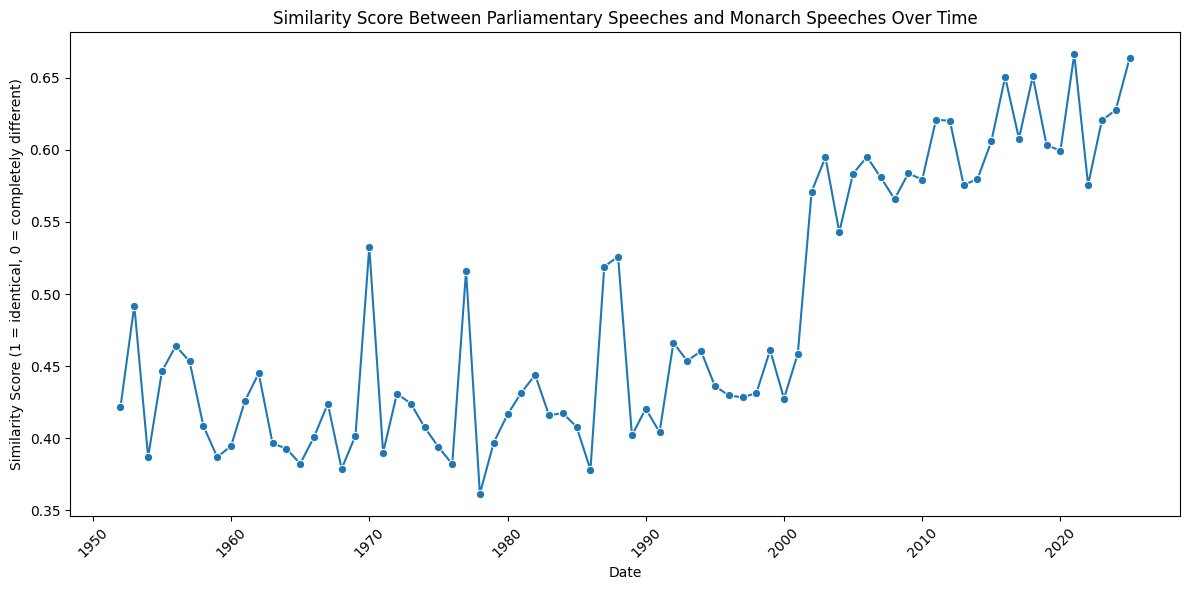

In [14]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_avg, x='year', y='similarity_score', marker='o')
plt.title('Similarity Score Between Parliamentary Speeches and Monarch Speeches Over Time')
plt.xlabel('Date')
plt.ylabel('Similarity Score (1 = identical, 0 = completely different)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()  

In [15]:
final_df['month'] = pd.to_datetime(final_df['date']).dt.to_period('M')
monthly_avg = final_df.groupby('month')['similarity_score'].mean().reset_index()
print(monthly_avg.to_string(index=False))

  month  similarity_score
1952-01          0.430655
1952-02          0.410438
1952-03          0.432276
1952-04          0.419591
1952-05          0.414874
1952-06          0.415441
1952-07          0.426592
1952-08          0.454916
1952-10          0.413521
1952-11          0.434857
1952-12          0.415796
1953-01          0.476774
1953-02          0.485914
1953-03          0.501916
1953-04          0.489408
1953-05          0.496925
1953-06          0.477715
1953-07          0.494821
1953-10          0.507365
1953-11          0.493922
1953-12          0.491858
1954-01          0.389443
1954-02          0.377707
1954-03          0.392534
1954-04          0.389492
1954-05          0.385152
1954-06          0.375107
1954-07          0.387120
1954-10          0.388335
1954-11          0.388080
1954-12          0.397878
1955-01          0.457086
1955-02          0.450573
1955-03          0.456853
1955-04          0.451671
1955-05          0.444635
1955-06          0.424606
1955-07     

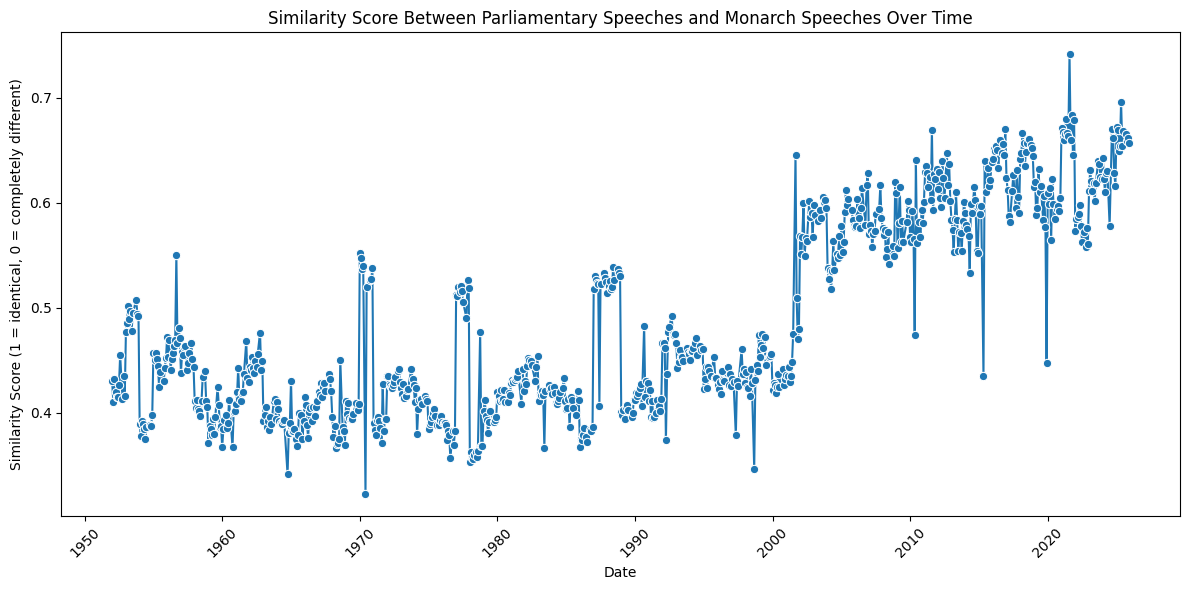

In [16]:
monthly_avg['month'] = monthly_avg['month'].dt.to_timestamp()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_avg, x='month', y='similarity_score', marker='o')
plt.title('Similarity Score Between Parliamentary Speeches and Monarch Speeches Over Time')
plt.xlabel('Date')
plt.ylabel('Similarity Score (1 = identical, 0 = completely different)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show() 

In [ ]:
speech_dates = royal_speeches.groupby('year')['date'].first().reset_index()
speech_dates = speech_dates.rename(columns={'date': 'speech_date'})

final_df = pd.merge(final_df, speech_dates, on='year', how='left')

final_df['time'] = (final_df['date'] - final_df['speech_date']).dt.days

final_df['post'] = (final_df['time'] > 0).astype(int)

final_df['time_x_post'] = final_df['time'] * final_df['post']

print(final_df[['date', 'speech_date', 'time', 'post', 'time_x_post', 'similarity_score']].head(10))

        date speech_date  time  post  time_x_post  similarity_score
0 1952-01-29  1952-12-25  -331     0            0          0.429552
1 1952-01-30  1952-12-25  -330     0            0          0.431000
2 1952-01-31  1952-12-25  -329     0            0          0.431413
3 1952-02-01  1952-12-25  -328     0            0          0.432006
4 1952-02-04  1952-12-25  -325     0            0          0.410480
5 1952-02-05  1952-12-25  -324     0            0          0.441963
6 1952-02-06  1952-12-25  -323     0            0          0.416464
7 1952-02-07  1952-12-25  -322     0            0          0.384154
8 1952-02-08  1952-12-25  -321     0            0          0.284740
9 1952-02-11  1952-12-25  -318     0            0          0.494739


In [ ]:
window_days = 14

windowed_df = final_df[
    (final_df['time'] >= -window_days) & 
    (final_df['time'] <= window_days)
].copy()

windowed_df = windowed_df[windowed_df['time'] != 0]

print(f"Dataframe reduced to {len(windowed_df)} valid parliamentary days within the +/- {window_days} day window.")
print(windowed_df['time'].value_counts().sort_index())

Dataframe reduced to 770 valid parliamentary days within the +/- 14 day window.
time
-14    47
-13    49
-12    47
-11    43
-10    42
-9     39
-8     43
-7     48
-6     48
-5     45
-4     35
-3     18
-2     15
-1     15
 1     21
 2     18
 3     14
 4     10
 5     11
 6     14
 7     24
 8     23
 9     20
 10    16
 11    12
 12    11
 13    16
 14    26
Name: count, dtype: int64


In [19]:
windowed_df

,date,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,...,topic_11_r,topic_12_r,topic_13_r,topic_14_r,similarity_score,month,speech_date,time,post,time_x_post
157,1952-12-11,0.117758,0.025103,0.025863,0.097817,0.093947,0.192080,0.113282,0.055218,0.014246,...,0.000283,0.100849,0.015330,0.000283,0.422345,1952-12,1952-12-25,-14,0,0
158,1952-12-12,0.101131,0.031568,0.018452,0.156963,0.079817,0.225849,0.102806,0.036679,0.011788,...,0.000283,0.100849,0.015330,0.000283,0.395565,1952-12,1952-12-25,-13,0,0
159,1952-12-15,0.130906,0.034259,0.024797,0.092792,0.087673,0.208133,0.097086,0.026612,0.018126,...,0.000283,0.100849,0.015330,0.000283,0.386487,1952-12,1952-12-25,-10,0,0
160,1952-12-16,0.140235,0.032658,0.019869,0.096997,0.093962,0.159901,0.113451,0.039610,0.016822,...,0.000283,0.100849,0.015330,0.000283,0.408599,1952-12,1952-12-25,-9,0,0
161,1952-12-17,0.134032,0.032412,0.020034,0.105229,0.094207,0.169017,0.110234,0.043069,0.016168,...,0.000283,0.100849,0.015330,0.000283,0.410302,1952-12,1952-12-25,-8,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11359,2025-01-21,0.023159,0.028301,0.059784,0.022802,0.039569,0.077315,0.167989,0.068815,0.034359,...,0.063491,0.181555,0.011624,0.027466,0.670817,2025-01,2025-01-13,8,1,8
11360,2025-01-22,0.023067,0.027498,0.057132,0.024582,0.039397,0.098175,0.152885,0.081062,0.035426,...,0.063491,0.181555,0.011624,0.027466,0.662061,2025-01,2025-01-13,9,1,9
11361,2025-01-23,0.020399,0.023783,0.038669,0.025687,0.046319,0.101197,0.178142,0.077236,0.035897,...,0.063491,0.181555,0.011624,0.027466,0.675880,2025-01,2025-01-13,10,1,10
11362,2025-01-24,0.018564,0.027393,0.037866,0.030066,0.036781,0.091272,0.212206,0.073875,0.039329,...,0.063491,0.181555,0.011624,0.027466,0.703656,2025-01,2025-01-13,11,1,11


In [ ]:
import statsmodels.formula.api as smf

formula = 'similarity_score ~ post + time + time_x_post + C(year)'

model = smf.ols(formula=formula, data=windowed_df)

results = model.fit(cov_type='HC1')

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:       similarity_score   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.925
Method:                 Least Squares   F-statistic:                     259.6
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:12:05   Log-Likelihood:                 1785.6
No. Observations:                 770   AIC:                            -3419.
Df Residuals:                     694   BIC:                            -3066.
Df Model:                          75                                         
Covariance Type:                  HC1                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.4050      0.006     

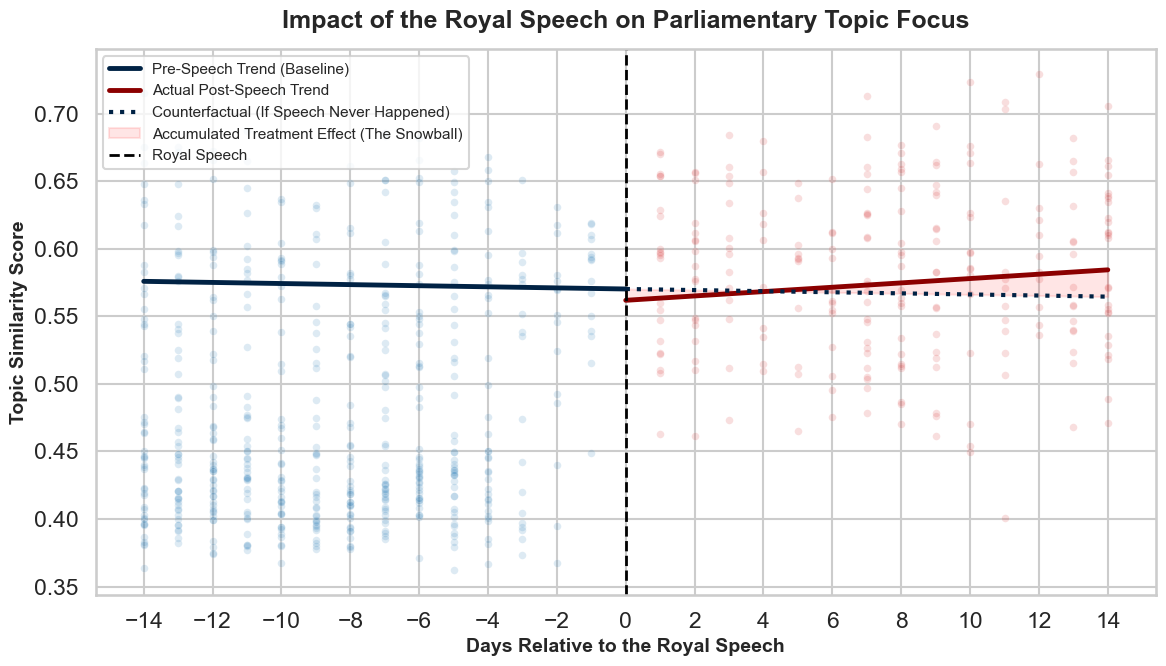

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", context="talk")

plt.figure(figsize=(12, 7))

pre_speech = windowed_df[windowed_df['time'] < 0]
post_speech = windowed_df[windowed_df['time'] > 0]

sns.scatterplot(x='time', y='similarity_score', data=pre_speech, alpha=0.15, color='#1f77b4', s=30)
sns.scatterplot(x='time', y='similarity_score', data=post_speech, alpha=0.15, color='#d62728', s=30)

c_time = results.params['time']
c_post = results.params['post']
c_interaction = results.params['time_x_post']

anchor_y = pre_speech[pre_speech['time'] == -1]['similarity_score'].mean()
base_intercept = anchor_y - (c_time * -1)

x_pre = np.arange(-window_days, 1)
y_pre = base_intercept + (c_time * x_pre)

x_post = np.arange(0, window_days + 1)
y_post_actual = base_intercept + c_post + ((c_time + c_interaction) * x_post)

y_post_counterfactual = base_intercept + (c_time * x_post)

plt.plot(x_pre, y_pre, color='#002244', linewidth=3.5, label='Pre-Speech Trend (Baseline)')
plt.plot(x_post, y_post_actual, color='#8b0000', linewidth=3.5, label='Actual Post-Speech Trend')

plt.plot(x_post, y_post_counterfactual, color='#002244', linewidth=3, linestyle=':', 
         label='Counterfactual (If Speech Never Happened)')

plt.fill_between(x_post, y_post_actual, y_post_counterfactual, color='red', alpha=0.1, 
                 label='Accumulated Treatment Effect (The Snowball)')

plt.axvline(x=0, color='black', linestyle='--', linewidth=2, label='Royal Speech')
plt.title("Impact of the Royal Speech on Parliamentary Topic Focus", fontsize=18, fontweight='bold', pad=15)
plt.xlabel("Days Relative to the Royal Speech", fontsize=14, fontweight='bold')
plt.ylabel("Topic Similarity Score", fontsize=14, fontweight='bold')

plt.xticks(range(-window_days, window_days + 1, 2))
plt.legend(loc='upper left', frameon=True, fontsize=11)
plt.tight_layout()

plt.show()

In [25]:
final_df

,date,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,...,topic_11_r,topic_12_r,topic_13_r,topic_14_r,similarity_score,month,speech_date,time,post,time_x_post
0,1952-01-29,0.119180,0.040354,0.023281,0.087074,0.083845,0.125554,0.110064,0.090086,0.006898,...,0.000283,0.100849,0.015330,0.000283,0.429552,1952-01,1952-12-25,-331,0,0
1,1952-01-30,0.129280,0.032516,0.026394,0.093924,0.108240,0.111152,0.104880,0.107501,0.024350,...,0.000283,0.100849,0.015330,0.000283,0.431000,1952-01,1952-12-25,-330,0,0
2,1952-01-31,0.136563,0.039382,0.040461,0.099946,0.092376,0.106060,0.109392,0.092050,0.026525,...,0.000283,0.100849,0.015330,0.000283,0.431413,1952-01,1952-12-25,-329,0,0
3,1952-02-01,0.126553,0.039339,0.036215,0.148093,0.079134,0.143161,0.121657,0.067441,0.028118,...,0.000283,0.100849,0.015330,0.000283,0.432006,1952-02,1952-12-25,-328,0,0
4,1952-02-04,0.116695,0.041579,0.012481,0.128076,0.093482,0.103984,0.099369,0.060333,0.015141,...,0.000283,0.100849,0.015330,0.000283,0.410480,1952-02,1952-12-25,-325,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11502,2025-12-11,0.020245,0.027787,0.064675,0.024749,0.042767,0.061517,0.190436,0.065117,0.052107,...,0.063491,0.181555,0.011624,0.027466,0.681021,2025-12,2025-01-13,332,1,332
11503,2025-12-15,0.027235,0.031706,0.053082,0.020764,0.036950,0.073450,0.175638,0.140077,0.035592,...,0.063491,0.181555,0.011624,0.027466,0.716509,2025-12,2025-01-13,336,1,336
11504,2025-12-16,0.025387,0.029085,0.037952,0.021877,0.036840,0.080537,0.152161,0.105179,0.047546,...,0.063491,0.181555,0.011624,0.027466,0.678724,2025-12,2025-01-13,337,1,337
11505,2025-12-17,0.027679,0.027688,0.047190,0.021664,0.038813,0.081312,0.151582,0.090281,0.045560,...,0.063491,0.181555,0.011624,0.027466,0.670185,2025-12,2025-01-13,338,1,338


In [ ]:
import statsmodels.formula.api as smf

full_df = final_df.copy()


full_df['placebo_time'] = full_df['time'] + 30 

placebo_window = full_df[
    (full_df['placebo_time'] >= -14) & 
    (full_df['placebo_time'] <= 14) & 
    (full_df['placebo_time'] != 0)
].copy()

placebo_window['placebo_post'] = (placebo_window['placebo_time'] > 0).astype(int)
placebo_window['placebo_time_x_post'] = placebo_window['placebo_time'] * placebo_window['placebo_post']

placebo_formula = 'similarity_score ~ placebo_post + placebo_time + placebo_time_x_post + C(year)'
placebo_model = smf.ols(formula=placebo_formula, data=placebo_window)
placebo_results = placebo_model.fit(cov_type='HC1')

print(placebo_results.summary())

                            OLS Regression Results                            
Dep. Variable:       similarity_score   R-squared:                       0.942
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     283.0
Date:                Wed, 18 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:06:35   Log-Likelihood:                 2852.8
No. Observations:                1123   AIC:                            -5570.
Df Residuals:                    1055   BIC:                            -5228.
Df Model:                          67                                         
Covariance Type:                  HC1                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.4236    

In [ ]:
import numpy as np
from scipy.spatial.distance import jensenshannon

def simulate_1_percent_shift(parliament_baseline, monarch_vector, shift_amount=0.01, iterations=1000):
    baseline_similarity = 1 - jensenshannon(parliament_baseline, monarch_vector)
    simulated_gains = []
    
    for _ in range(iterations):
        sim_parliament = np.copy(parliament_baseline)
        

        target_topic = np.random.choice(len(monarch_vector), p=monarch_vector)
        sim_parliament[target_topic] += shift_amount
        
        other_topics = [i for i in range(len(monarch_vector)) if i != target_topic]
        sum_others = np.sum(sim_parliament[other_topics])
        
        for i in other_topics:
            sim_parliament[i] -= shift_amount * (sim_parliament[i] / sum_others)
            
        new_similarity = 1 - jensenshannon(sim_parliament, monarch_vector)
        simulated_gains.append(new_similarity - baseline_similarity)
        
    return np.mean(simulated_gains)

parl_topic_cols = [col for col in final_df.columns if col.startswith('topic_') and not col.endswith('_r')]


pre_speech_df = final_df[(final_df['time'] < 0) & (final_df['time'] >= -14)]
parliament_baseline = pre_speech_df[parl_topic_cols].mean().values

monarch_df = final_df[final_df['time'] == 0]
monarch_vector = monarch_df[parl_topic_cols].mean().values


# Your actual regression coefficient
actual_daily_coefficient = 0.0020 

average_simulated_gain = simulate_1_percent_shift(parliament_baseline, monarch_vector)

equivalent_percentage_shift = actual_daily_coefficient / average_simulated_gain

print("SIMULATION RESULTS:")
print(f"A simulated 1% shift yields an average similarity increase of: {average_simulated_gain:.6f}")
print(f"Your daily momentum coefficient (0.0020) equals roughly a {equivalent_percentage_shift:.2f}% shift.\n")

--- SIMULATION RESULTS ---
A simulated 1% shift yields an average similarity increase of: 0.000360
Your daily momentum coefficient (0.0020) equals roughly a 5.56% shift.

